# **Monthly Embeddings from Prithvi-EO: Does Temporal Resolution Beat AlphaEarth's Annual Vector?**

Run a second geo foundation model, NASA and IBM's Prithvi-EO-2.0, on monthly satellite imagery at every tower, and test whether a *monthly* learned surface description predicts ET and GPP better than AlphaEarth's *annual* one.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Explain the difference between a foundation model that ships as a **product** (AlphaEarth: precomputed annual embeddings) and one that ships as a **model** you run yourself (Prithvi-EO: a vision transformer for Harmonized Landsat Sentinel-2 imagery).
- Describe how a masked-autoencoder embedding is produced from a 6-band image chip, why it comes in 480 m patches, and what compressing 1024 dimensions to 64 does.
- Separate two effects that are usually confounded: the *model* (Prithvi versus AlphaEarth) and the *temporal resolution* of the surface description (monthly versus seasonal versus annual).
- Decompose predictive skill into a between-site part and a within-year part, and see which inputs carry each.
- Judge the maps that result, at 480 m, against OpenET and the withheld Vaira Ranch tower.

**Before you start:** Notebook 12 (this is a direct continuation and reuses its data and models). Packages: `scikit-learn`, `rasterio`. Runs in about 10 minutes.

## **Two foundation models, two philosophies**

Notebook 12 ended with a clear diagnosis. AlphaEarth's embedding is an excellent description of *what* a surface is, but it is annual: it cannot see the grass die in June or the field being harvested in August. Monthly NDVI supplied that phenology and improved every model. The obvious next question is whether a foundation model can supply the phenology too, and do it better than a hand-made index.

| | AlphaEarth Foundations (Google DeepMind) | Prithvi-EO-2.0 (NASA and IBM) |
|---|---|---|
| What you get | A **product**: one 64-D vector per 10 m pixel per year, 2017-2024, ready in Earth Engine | A **model**: 300 million (or 600 million) parameters that you run on your own imagery |
| Input | Sentinel-2, Landsat, Sentinel-1 radar, thermal, lidar-derived height, climate, terrain, the whole year at once | Six bands of Harmonized Landsat Sentinel-2 (HLS) surface reflectance at 30 m, one or more dates |
| Training objective | An "embedding field" model trained so that vectors of similar places are close and support linear readout (Brown et al., 2025) | A masked autoencoder: hide 75% of the image patches and reconstruct them (Szwarcman et al., 2024) |
| Output | 64 numbers, unit length, meaningful as a vector | 1024 numbers for every 16 x 16 pixel patch (480 m), plus a class token |
| Temporal resolution | Annual, fixed | Whatever you feed it: a single date, a monthly composite, or up to several dates in one pass |
| Cost to use | Free, no compute | Free weights (Apache 2.0), but you need imagery, cloud masking, and a GPU or patience |

The two objectives matter for what to expect. AlphaEarth was *optimized* to produce a compact, semantically organized vector. Prithvi was optimized to *reconstruct pixels*; its encoder learns whatever helps that, and the resulting features are known to work well after fine-tuning but are not guaranteed to be linearly readable when frozen. We use both models frozen, as a hydrologist without a GPU cluster would.

### **How the Prithvi embeddings were made**

For each of the 1,306 tower-years with flux data, and for the Vaira region in 2021 and 2023, `prep_prithvi_hls.py` built **monthly cloud-masked median composites** of HLS (Landsat 8/9 and Sentinel-2 harmonized, 30 m) on 96 x 96 pixel chips (2.9 km) centered on the tower. Gaps left by clouds were filled from the nearest month with data. `prithvi_embed.py` then ran the Prithvi-EO-2.0-300M encoder on each monthly chip (roughly 16,000 forward passes) and kept the mean token of the four 480 m patches around the tower, a 960 m footprint. Because 1024 dimensions are unwieldy and unfair against a 64-D competitor, the vectors were reduced to **64 principal components** fitted on the tower chips. Two more Prithvi descriptions were derived: an **annual** one (the mean of the twelve monthly vectors, the fair counterpart of AlphaEarth) and a **seasonal** one (January, April, July and October composites fed to the model *together*, so that its temporal attention sees the year in one pass).

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject, Resampling
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file (may include a sub-folder), downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    out = os.path.join('sample_data', fname)
    os.makedirs(os.path.dirname(out), exist_ok=True)
    urllib.request.urlretrieve(BASE + fname.replace(os.sep, '/'), out)
    return out

files = ['alphaearth/sites.csv', 'alphaearth/site_year_embeddings.csv', 'alphaearth/site_month_data.csv',
         'alphaearth/prithvi_site_month_pca64.csv', 'alphaearth/prithvi_site_seasonal_pca64.csv', 'alphaearth/prithvi_pca.npz']
paths = {f: get_data(f) for f in files}

sites = pd.read_csv(paths['alphaearth/sites.csv']).set_index('site_id')
emb = pd.read_csv(paths['alphaearth/site_year_embeddings.csv'])
mon = pd.read_csv(paths['alphaearth/site_month_data.csv'])
pm = pd.read_csv(paths['alphaearth/prithvi_site_month_pca64.csv'])
ps = pd.read_csv(paths['alphaearth/prithvi_site_seasonal_pca64.csv'])
pca_info = np.load(paths['alphaearth/prithvi_pca.npz'])
EMB = [f'A{i:02d}' for i in range(64)]      # AlphaEarth, annual
PM = [f'P{i:02d}' for i in range(64)]       # Prithvi, monthly
PS = [f'S{i:02d}' for i in range(64)]       # Prithvi, seasonal (4 frames in one pass)
print(f'{len(pm)} Prithvi monthly embeddings at {pm.site_id.nunique()} towers; {len(ps)} seasonal embeddings')
print(f"The 64 principal components keep {pca_info['monthly_explained'].sum()*100:.0f}% of the variance of the 1024-D monthly tokens "
      f"and {pca_info['seasonal_explained'].sum()*100:.0f}% of the seasonal ones")
print(f"{(pm.hls_valid_frac < 0.5).mean()*100:.0f}% of monthly chips had less than half their pixels observed and were mostly gap-filled")

15672 Prithvi monthly embeddings at 273 towers; 1306 seasonal embeddings
The 64 principal components keep 93% of the variance of the 1024-D monthly tokens and 94% of the seasonal ones
6% of monthly chips had less than half their pixels observed and were mostly gap-filled


## **Step 1: What does a monthly embedding look like?**

Two views. First the same projection we used for AlphaEarth: the monthly Prithvi vectors of 2021 in two dimensions, colored by land-cover class. Second, the thing an annual embedding cannot show: the **trajectory** of one site through the year. Vaira Ranch (annual grassland) and an eastern deciduous forest both have strong seasons; a Sonoran shrubland (US-xSR) barely changes.

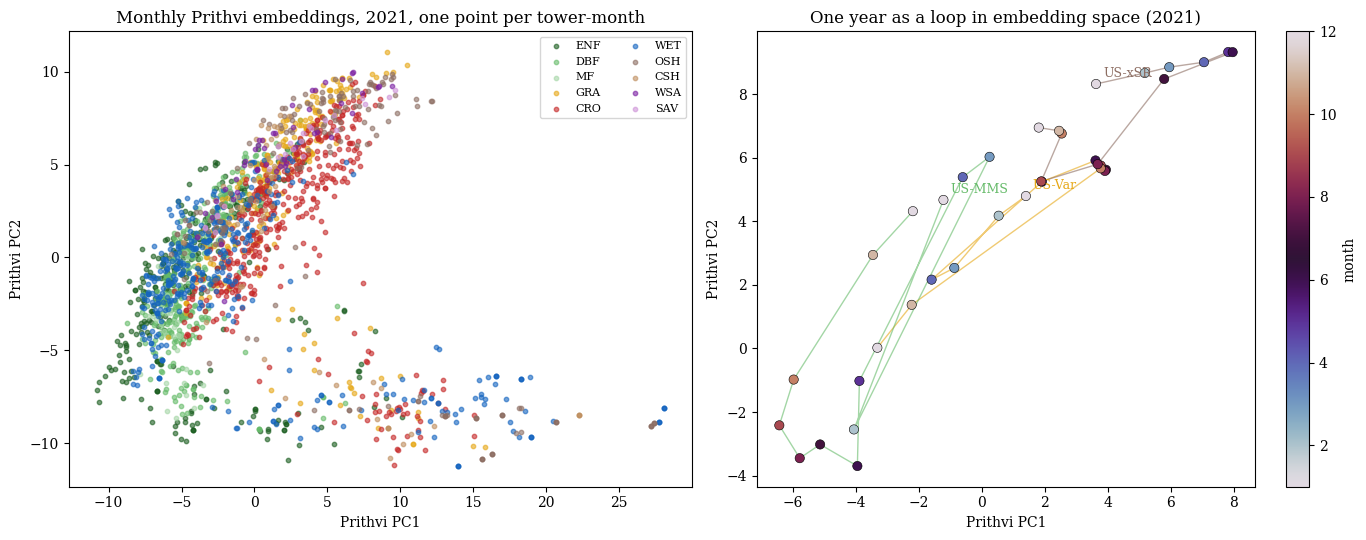

In [2]:
igbp_all = sites['igbp']
main_classes = ['ENF', 'DBF', 'MF', 'GRA', 'CRO', 'WET', 'OSH', 'CSH', 'WSA', 'SAV']
class_colors = dict(zip(main_classes, ['#1b5e20', '#66bb6a', '#a5d6a7', '#e6a817', '#c62828', '#1565c0', '#8d6e63', '#bf8f5f', '#7b1fa2', '#ce93d8']))

p21 = pm[pm.year == 2021].copy(); p21['igbp'] = igbp_all.loc[p21.site_id].values
full = p21.groupby('site_id').size(); full = full[full == 12].index
def pick(cands):
    return next(s for s in cands if s in full)
DBF_SITE = pick(['US-UMB', 'US-MMS', 'US-Ha1', 'US-Bar', 'US-xSC', 'US-xRN', 'US-Oho'])
SHOW = [('US-Var', '#e6a817'), (DBF_SITE, '#66bb6a'), ('US-xSR', '#8d6e63')]
fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axs[0]
for c in main_classes:
    sel = p21.igbp == c
    if sel.sum():
        ax.scatter(p21.loc[sel, 'P00'], p21.loc[sel, 'P01'], s=10, alpha=0.6, color=class_colors[c], label=f'{c}')
ax.set_xlabel('Prithvi PC1'); ax.set_ylabel('Prithvi PC2'); ax.legend(fontsize=8, ncol=2)
ax.set_title('Monthly Prithvi embeddings, 2021, one point per tower-month')

ax = axs[1]
for site, color in SHOW:
    tr = p21[p21.site_id == site].sort_values('month')
    if len(tr):
        ax.plot(tr.P00, tr.P01, '-', color=color, lw=1, alpha=0.6)
        sc = ax.scatter(tr.P00, tr.P01, c=tr.month, cmap='twilight', s=45, edgecolor='k', linewidth=0.4, vmin=1, vmax=12, zorder=3)
        ax.annotate(site, (tr.P00.iloc[0], tr.P01.iloc[0]), fontsize=9, color=color, xytext=(5, 5), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='month'); ax.set_xlabel('Prithvi PC1'); ax.set_ylabel('Prithvi PC2')
ax.set_title('One year as a loop in embedding space (2021)'); plt.tight_layout()

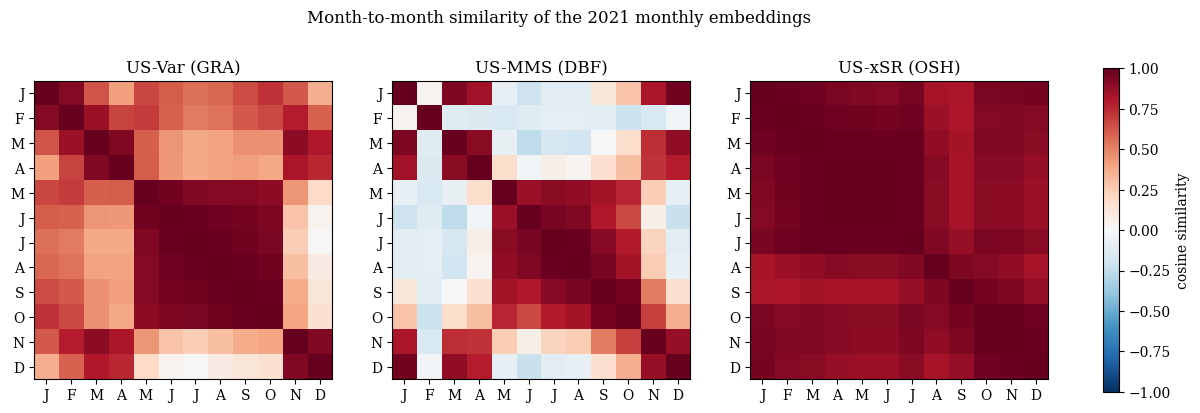

In [3]:
def cosine_matrix(X):
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    return Xn @ Xn.T

months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (site, _) in zip(axs, SHOW):
    tr = p21[p21.site_id == site].sort_values('month')
    if len(tr) == 12:
        im = ax.imshow(cosine_matrix(tr[PM].values), vmin=-1, vmax=1, cmap='RdBu_r')
        ax.set_xticks(range(12)); ax.set_yticks(range(12)); ax.set_xticklabels(months); ax.set_yticklabels(months)
        ax.set_title(f'{site} ({igbp_all[site]})')
plt.colorbar(im, ax=axs, fraction=0.015, label='cosine similarity'); fig.suptitle('Month-to-month similarity of the 2021 monthly embeddings', y=1.02); plt.show()

The grassland and the deciduous forest trace loops: winter and summer sit in different corners of embedding space and the year comes back to where it started. The shrubland barely moves. This is the phenology that Notebook 12 had to import through NDVI, now inside the learned representation, and with 64 dimensions instead of one index. Whether a random forest can use it better than NDVI is the question of the next step.

## **Step 2: Assemble the table and define the experiments**

We rebuild the Notebook 12 training table (same derived meteorology, same targets, same quality control) and attach three Prithvi descriptions to each tower-month:

- **P-monthly**: the embedding of that month's composite.
- **P-annual**: the mean of the twelve monthly embeddings of that tower-year (comparable to AlphaEarth's annual vector; averaging is legitimate because the PCA is linear).
- **P-seasonal**: the four-frame embedding of that tower-year.

The model set is designed so that each comparison changes one thing at a time:

| Model | Surface description | Isolates |
|---|---|---|
| AE-annual | AlphaEarth (Notebook 12, Model B) | the reference |
| P-annual | Prithvi, mean of 12 months | *model* at equal (annual) resolution |
| P-seasonal | Prithvi, 4 dates in one pass | Prithvi's own temporal attention |
| P-monthly | Prithvi, this month | *temporal resolution*, same model |
| AE + NDVI | AlphaEarth + monthly indices (Notebook 12, Model B+) | hand-made phenology |
| AE + P-monthly | both foundation models | learned phenology on top of AlphaEarth |
| AE + P-monthly + NDVI | everything | ceiling |

All models also receive the same monthly Daymet meteorology. Evaluation is leave-site-out with the same five folds as before.

In [4]:
def esat(T):
    return 0.6108 * np.exp(17.27 * T / (T + 237.3))

def extraterrestrial_radiation(lat_deg, doy):
    phi = np.radians(lat_deg); dr = 1 + 0.033 * np.cos(2 * np.pi * doy / 365); dec = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)
    ws = np.arccos(np.clip(-np.tan(phi) * np.tan(dec), -1, 1))
    return 24 * 60 / np.pi * 0.0820 * dr * (ws * np.sin(phi) * np.sin(dec) + np.cos(phi) * np.cos(dec) * np.sin(ws))

def add_met_features(df, lat):
    df['tmean'] = (df.tmax + df.tmin) / 2
    df['vpd'] = np.clip((esat(df.tmax) + esat(df.tmin)) / 2 - df.vp / 1000, 0, None)
    df['rs'] = df.srad * df.dayl / 1e6; df['dayl_h'] = df.dayl / 3600
    ra = extraterrestrial_radiation(lat, 15 + 30.4 * (df.month - 1))
    df['et0_hg'] = 0.0023 * (df.tmean + 17.8) * np.sqrt(np.clip(df.tmax - df.tmin, 0, None)) * ra / 2.45
    df['month_sin'] = np.sin(2 * np.pi * df.month / 12); df['month_cos'] = np.cos(2 * np.pi * df.month / 12)
    return df

mon = mon.sort_values(['site_id', 'year', 'month']).reset_index(drop=True)
mon = add_met_features(mon, sites.loc[mon.site_id, 'lat'].values)
mon['prcp_3m'] = mon.groupby('site_id').prcp.transform(lambda s: s.rolling(3, min_periods=1).mean())
g = mon.groupby('site_id').ndvi_landsat
mon['ndvi'] = ((g.ffill() + g.bfill()) / 2).fillna(g.ffill()).fillna(g.bfill()).fillna(mon.ndvi_modis)
mon['ET'] = np.where(mon.LE_F_MDS_QC >= 0.7, mon.ET_obs_corr, np.nan)
mon['GPP'] = np.where(mon.NEE_VUT_REF_QC >= 0.7, np.clip(mon.GPP_obs, 0, None), np.nan)
mon['igbp'] = sites.loc[mon.site_id, 'igbp'].values
mon = mon.merge(emb, on=['site_id', 'year'], how='left')

# Prithvi: monthly, annual (mean of the 12 months), seasonal
PA = [f'PA{i:02d}' for i in range(64)]
p_annual = pm.groupby(['site_id', 'year'])[PM].mean(); p_annual.columns = PA
mon = mon.merge(pm[['site_id', 'year', 'month', 'hls_valid_frac'] + PM], on=['site_id', 'year', 'month'], how='left')
mon = mon.merge(p_annual.reset_index(), on=['site_id', 'year'], how='left')
mon = mon.merge(ps, on=['site_id', 'year'], how='left')

MET = ['tmean', 'tmax', 'tmin', 'vpd', 'rs', 'dayl_h', 'prcp', 'prcp_3m', 'et0_hg', 'month_sin', 'month_cos']
VEG = ['ndvi', 'ndvi_modis', 'evi_modis', 'lai_modis', 'fpar_modis']
FEAT = {'AE-annual': MET + EMB,
        'P-annual': MET + PA,
        'P-seasonal': MET + PS,
        'P-monthly': MET + PM,
        'AE + NDVI': MET + VEG + EMB,
        'AE + P-monthly': MET + EMB + PM,
        'AE + P-monthly + NDVI': MET + VEG + EMB + PM}
MODELS = list(FEAT)
MODEL_COLORS = dict(zip(MODELS, ['#E69F00', '#56B4E9', '#009E73', '#0072B2', '#D55E00', '#CC79A7', '#000000']))
ALL_PRED = sorted(set(sum(FEAT.values(), [])))
data = {t: mon.dropna(subset=ALL_PRED + [t]).copy() for t in ['ET', 'GPP']}
for t, d in data.items():
    print(f'{t}: {len(d)} site-months from {d.site_id.nunique()} sites')

ET: 9274 site-months from 203 sites
GPP: 10491 site-months from 239 sites


ET: 7 models cross-validated, 79 s


GPP: 7 models cross-validated, 176 s


R2   RMSE   bias        n
target model                                              
ET     AE-annual              0.814  0.673 -0.006   9274.0
       P-annual               0.778  0.735 -0.001   9274.0
       P-seasonal             0.746  0.786 -0.016   9274.0
       P-monthly              0.817  0.668 -0.005   9274.0
       AE + NDVI              0.827  0.649 -0.011   9274.0
       AE + P-monthly         0.835  0.634 -0.006   9274.0
       AE + P-monthly + NDVI  0.834  0.637 -0.014   9274.0
GPP    AE-annual              0.810  1.791  0.038  10491.0
       P-annual               0.709  2.215  0.108  10491.0
       P-seasonal             0.708  2.218  0.068  10491.0
       P-monthly              0.818  1.753  0.039  10491.0
       AE + NDVI              0.870  1.481  0.037  10491.0
       AE + P-monthly         0.844  1.622  0.048  10491.0
       AE + P-monthly + NDVI  0.868  1.495  0.033  10491.0

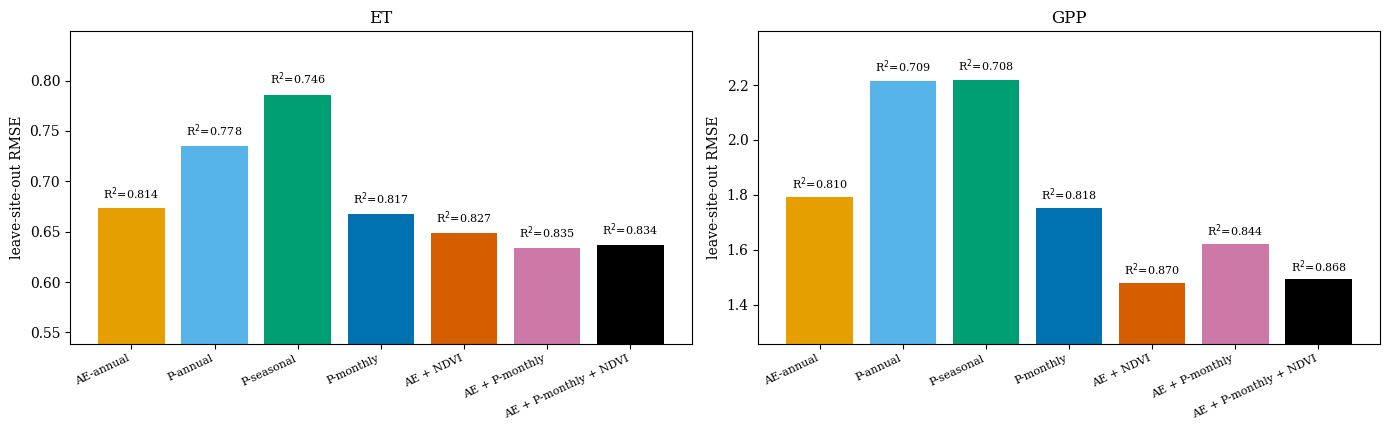

In [5]:
def metrics(obs, sim):
    m = np.isfinite(obs) & np.isfinite(sim); obs, sim = obs[m], sim[m]
    return {'R2': r2_score(obs, sim), 'RMSE': np.sqrt(mean_squared_error(obs, sim)), 'bias': np.mean(sim - obs), 'n': len(obs)}

def rf():
    return RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.33, n_jobs=-1, random_state=0)

def cv_predict(df, features, target, make_model, n_splits=5):
    pred = pd.Series(np.nan, index=df.index)
    for tr, te in GroupKFold(n_splits).split(df, groups=df.site_id):
        m = make_model().fit(df.iloc[tr][features], df.iloc[tr][target])
        pred.iloc[te] = m.predict(df.iloc[te][features])
    return pred

results, preds = {}, {}
t0 = time.time()
for t in ['ET', 'GPP']:
    d = data[t]
    for k in MODELS:
        preds[(t, k)] = cv_predict(d, FEAT[k], t, rf)
        results[(t, k)] = metrics(d[t].values, preds[(t, k)].values)
    print(f'{t}: {len(MODELS)} models cross-validated, {time.time()-t0:.0f} s')
res = pd.DataFrame(results).T.round(3); res.index.names = ['target', 'model']
display(res)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, t in zip(axs, ['ET', 'GPP']):
    r = res.loc[t].loc[MODELS]
    ax.bar(range(len(MODELS)), r.RMSE, color=[MODEL_COLORS[m] for m in MODELS])
    for i, (m, row) in enumerate(r.iterrows()):
        ax.text(i, row.RMSE * 1.01, f"R$^2$={row.R2:.3f}", ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(r.RMSE.min() * 0.85, r.RMSE.max() * 1.08); ax.set_ylabel('leave-site-out RMSE'); ax.set_title(t)
plt.tight_layout()

### **Where does the skill come from? Between sites versus within the year**

A monthly ET series has two kinds of variance: the difference between a wetland and a desert (between site-years) and the seasonal cycle within a year (within site-years). An annual surface description can only help with the first; phenology, whether from NDVI or from monthly embeddings, targets the second. We split every model's cross-validated skill into these two parts without retraining: the between part is the R$^2$ of the site-year means, the within part is the R$^2$ of the monthly anomalies from those means.

between site-years R2  within-year anomaly R2
target model                                                               
ET     AE-annual                              0.770                   0.832
       P-annual                               0.730                   0.798
       P-seasonal                             0.684                   0.777
       P-monthly                              0.754                   0.842
       AE + NDVI                              0.759                   0.851
       AE + P-monthly                         0.792                   0.851
       AE + P-monthly + NDVI                  0.771                   0.856
GPP    AE-annual                              0.766                   0.836
       P-annual                               0.683                   0.736
       P-seasonal                             0.696                   0.730
       P-monthly                              0.786                   0.839
       AE + NDVI                              0.832                   0.889
       AE + P-monthly                         0.816                   0.862
       AE + P-monthly + NDVI                  0.830                   0.886

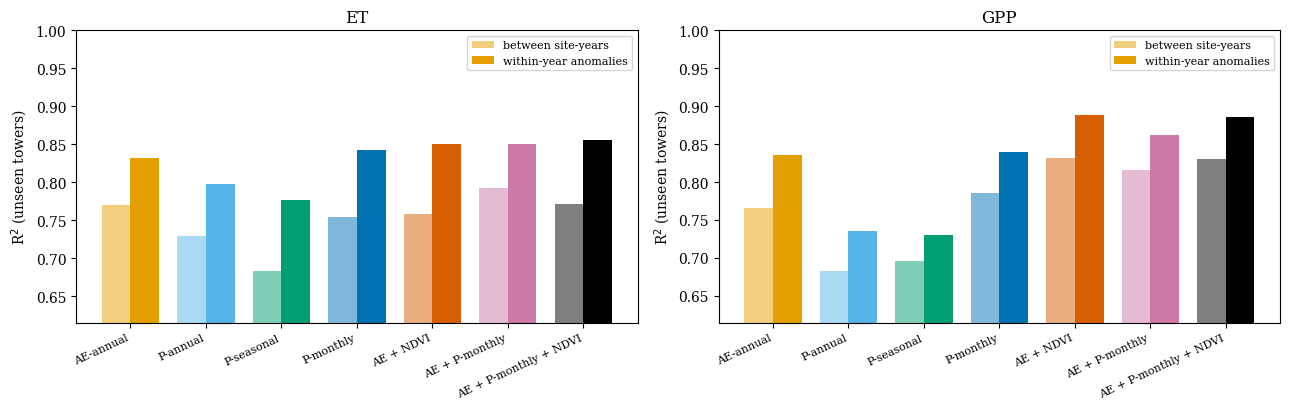

In [6]:
rows = []
for t in ['ET', 'GPP']:
    d = data[t]
    for k in MODELS:
        p = preds[(t, k)]
        df = pd.DataFrame({'obs': d[t].values, 'sim': p.values, 'sy': d.site_id + '_' + d.year.astype(str)})
        means = df.groupby('sy')[['obs', 'sim']].mean()
        anom = df[['obs', 'sim']] - df.sy.map(means.obs).values[:, None] * [1, 0] - df.sy.map(means.sim).values[:, None] * [0, 1]
        rows.append({'target': t, 'model': k, 'between site-years R2': r2_score(means.obs, means.sim),
                     'within-year anomaly R2': r2_score(anom.obs, anom.sim)})
decomp = pd.DataFrame(rows).set_index(['target', 'model']).round(3)
display(decomp)
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, t in zip(axs, ['ET', 'GPP']):
    dd = decomp.loc[t].loc[MODELS]
    x = np.arange(len(MODELS)); w = 0.38
    ax.bar(x - w/2, dd['between site-years R2'], w, color=[MODEL_COLORS[m] for m in MODELS], alpha=0.5, label='between site-years')
    ax.bar(x + w/2, dd['within-year anomaly R2'], w, color=[MODEL_COLORS[m] for m in MODELS], label='within-year anomalies')
    ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=25, ha='right', fontsize=8); ax.set_ylabel('R$^2$ (unseen towers)'); ax.set_title(t)
    ax.set_ylim(min(dd.min()) * 0.9, 1.0); ax.legend(fontsize=8)
plt.tight_layout()

### **Skill by land-cover class and label efficiency**

Same two diagnostics as Notebook 12, for the four models that matter most: AlphaEarth annual, Prithvi monthly, AlphaEarth plus NDVI, and AlphaEarth plus Prithvi monthly.

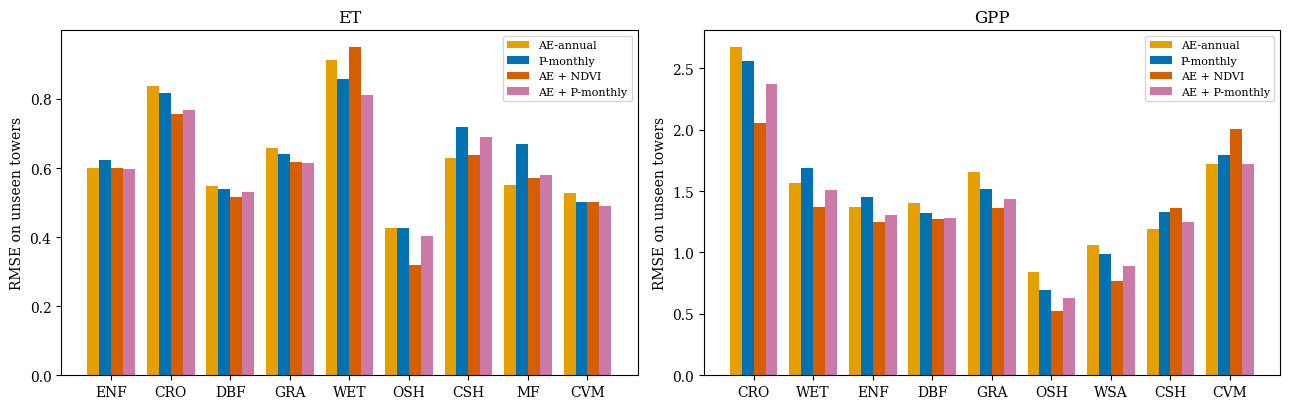

In [7]:
KEY4 = ['AE-annual', 'P-monthly', 'AE + NDVI', 'AE + P-monthly']
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, t in zip(axs, ['ET', 'GPP']):
    d = data[t]; classes = d.groupby('igbp').size().sort_values(ascending=False).index[:9]; w = 0.2
    for j, k in enumerate(KEY4):
        rm = [metrics(d[d.igbp == c][t].values, preds[(t, k)][d.igbp == c].values)['RMSE'] for c in classes]
        ax.bar(np.arange(len(classes)) + (j - 1.5) * w, rm, w, color=MODEL_COLORS[k], label=k)
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes); ax.set_ylabel('RMSE on unseen towers'); ax.set_title(t); ax.legend(fontsize=8)
plt.tight_layout()

learning curves in 63 s


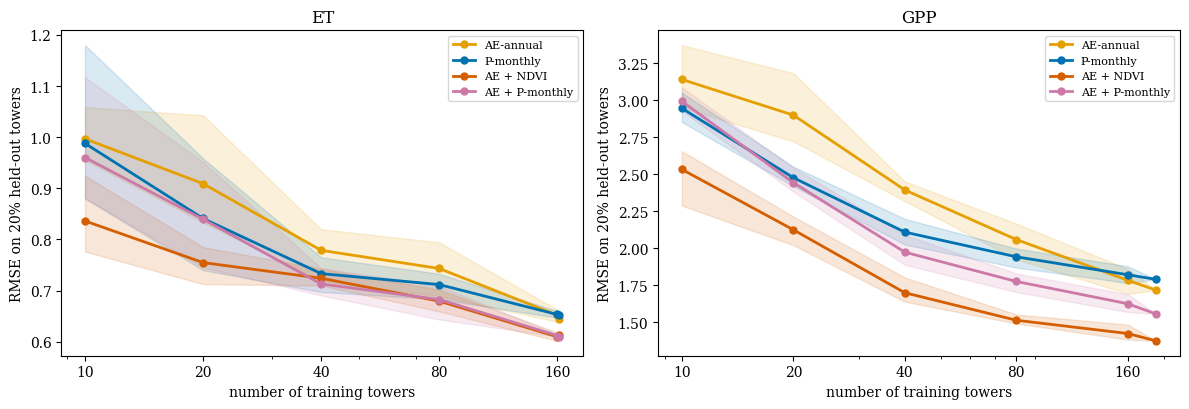

In [8]:
def learning_curve(t, sizes=(10, 20, 40, 80, 160), n_rep=3, n_estimators=100):
    d = data[t]
    tr_idx, te_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1).split(d, groups=d.site_id))
    train, test = d.iloc[tr_idx], d.iloc[te_idx]; pool = train.site_id.unique(); rng = np.random.default_rng(0); out = []
    for n in [s for s in sizes if s < len(pool)] + [len(pool)]:
        for rep in range(n_rep if n < len(pool) else 1):
            sub = train[train.site_id.isin(rng.choice(pool, size=n, replace=False))]
            for k in KEY4:
                m = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=5, max_features=0.33, n_jobs=-1, random_state=rep).fit(sub[FEAT[k]], sub[t])
                out.append({'n_sites': n, 'rep': rep, 'model': k, **metrics(test[t].values, m.predict(test[FEAT[k]]))})
    return pd.DataFrame(out)

t0 = time.time(); lc = {t: learning_curve(t) for t in ['ET', 'GPP']}; print(f'learning curves in {time.time()-t0:.0f} s')
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, t in zip(axs, ['ET', 'GPP']):
    g = lc[t].groupby(['model', 'n_sites']).RMSE.agg(['mean', 'min', 'max']).reset_index()
    for k in KEY4:
        gg = g[g.model == k]
        ax.plot(gg.n_sites, gg['mean'], 'o-', color=MODEL_COLORS[k], label=k, lw=2, ms=5); ax.fill_between(gg.n_sites, gg['min'], gg['max'], color=MODEL_COLORS[k], alpha=0.15)
    ax.set_xscale('log'); ax.set_xticks([10, 20, 40, 80, 160]); ax.set_xticklabels([10, 20, 40, 80, 160])
    ax.set_xlabel('number of training towers'); ax.set_ylabel('RMSE on 20% held-out towers'); ax.set_title(t); ax.legend(fontsize=8)
plt.tight_layout()

## **Step 3: Maps at Prithvi's resolution**

Prithvi's patches are 480 m, so its maps live on a 480 m grid: 90 x 90 cells over the Vaira region instead of the 403 x 409 cells of Notebook 12. Every other predictor is brought onto that grid. AlphaEarth is averaged from 100 m to 480 m, which its designers explicitly allow (embeddings are linearly composable); Daymet and MODIS are resampled up; Landsat NDVI and OpenET are averaged down. As in Notebook 12 the map models are trained without US-Var and US-Ton.

In [9]:
REGION = ['prithvi_monthly_2021_480m.tif', 'alphaearth_embedding_2021_100m.tif', 'landsat_ndvi_monthly_2021_100m.tif', 'openet_ensemble_et_monthly_2021_100m.tif',
          'elevation_100m.tif', 'daymet_monthly_2017_2024_1km.tif', 'modis_vegetation_monthly_2017_2024_500m.tif', 'mod16_et_monthly_2017_2024_500m.tif',
          'mod17_gpp_monthly_2017_2024_500m.tif', 'modis_landcover_2021_500m.tif']
rpaths = {f: get_data('alphaearth/region/' + f) for f in REGION}

def read_tif(fname):
    with rasterio.open(rpaths[fname]) as src:
        arr = src.read().astype('float32')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        arr[~np.isfinite(arr)] = np.nan
        arr *= float(src.tags().get('scale_factor', 1))
        return arr, list(src.descriptions), src.transform, src.crs

def to_grid(arr, src_transform, src_crs, like_shape, like_transform, like_crs, method=Resampling.average):
    out = np.full((arr.shape[0],) + like_shape, np.nan, dtype='float32')
    for i in range(arr.shape[0]):
        reproject(arr[i], out[i], src_transform=src_transform, src_crs=src_crs, dst_transform=like_transform, dst_crs=like_crs,
                  src_nodata=np.nan, dst_nodata=np.nan, resampling=method)
    return out

P21, p_names, T480, CRS = read_tif('prithvi_monthly_2021_480m.tif')
SHAPE = P21.shape[1:]
P21 = P21.reshape(12, 64, *SHAPE)                                             # month, component, row, col
E100, _, T100, _ = read_tif('alphaearth_embedding_2021_100m.tif'); E480 = to_grid(E100, T100, CRS, SHAPE, T480, CRS)
ls100, _, _, _ = read_tif('landsat_ndvi_monthly_2021_100m.tif'); ls480 = to_grid(ls100, T100, CRS, SHAPE, T480, CRS)
op100, _, _, _ = read_tif('openet_ensemble_et_monthly_2021_100m.tif'); openet = to_grid(op100, T100, CRS, SHAPE, T480, CRS)
el100, _, _, _ = read_tif('elevation_100m.tif'); elev = to_grid(el100, T100, CRS, SHAPE, T480, CRS)[0]
lc500, _, T500, _ = read_tif('modis_landcover_2021_500m.tif'); lc = to_grid(lc500, T500, CRS, SHAPE, T480, CRS, Resampling.nearest)[0]
daymet, dm_names, T1k, _ = read_tif('daymet_monthly_2017_2024_1km.tif')
modis, md_names, _, _ = read_tif('modis_vegetation_monthly_2017_2024_500m.tif')
mod16, m16_names, _, _ = read_tif('mod16_et_monthly_2017_2024_500m.tif'); m16 = to_grid(mod16[[m16_names.index(f'2021-{m:02d}') for m in range(1, 13)]], T500, CRS, SHAPE, T480, CRS, Resampling.bilinear)
mod17, m17_names, _, _ = read_tif('mod17_gpp_monthly_2017_2024_500m.tif'); m17 = to_grid(mod17[[m17_names.index(f'2021-{m:02d}') for m in range(1, 13)]], T500, CRS, SHAPE, T480, CRS, Resampling.bilinear)
water = lc == 17
for a in (openet, m16, m17):
    a[:, water] = np.nan

rows_, cols_ = np.indices(SHAPE)
xs = T480.c + (cols_ + 0.5) * T480.a; ys = T480.f + (rows_ + 0.5) * T480.e
lon_g, lat_g = rasterio.warp.transform(CRS, 'EPSG:4326', xs.ravel(), ys.ravel()); lat_g = np.array(lat_g).reshape(SHAPE)
extent_km = [0, SHAPE[1] * 0.48, 0, SHAPE[0] * 0.48]
def tower_rc(site):
    x, y = rasterio.warp.transform('EPSG:4326', CRS, [sites.loc[site, 'lon']], [sites.loc[site, 'lat']]); return rasterio.transform.rowcol(T480, x[0], y[0])
def tower_km(site):
    r, c = tower_rc(site); return (c + 0.5) * 0.48, (SHAPE[0] - r - 0.5) * 0.48
print('480 m grid:', SHAPE, '; Prithvi embedding present on', f'{np.isfinite(P21[0, 0]).mean()*100:.0f}% of cells')

480 m grid: (90, 90) ; Prithvi embedding present on 100% of cells


In [10]:
MAP_MODELS = ['AE-annual', 'P-monthly', 'AE + NDVI', 'AE + P-monthly']
MAP_PRED = sorted(set(sum((FEAT[k] for k in MAP_MODELS), [])))     # the seasonal embedding has no map, so it is not needed here

def fill_time(a):
    df = pd.DataFrame(a); f = df.ffill().values; b = df.bfill().values
    return np.where(np.isnan(f), b, np.where(np.isnan(b), f, (f + b) / 2))

def region_features(year=2021):
    dm_vars = ['tmax', 'tmin', 'srad', 'vp', 'dayl', 'prcp']
    keys = [f'{year-1}-11', f'{year-1}-12'] + [f'{year}-{m:02d}' for m in range(1, 13)]
    dm = to_grid(daymet[[dm_names.index(f'{v}_{k}') for k in keys for v in dm_vars]], T1k, CRS, SHAPE, T480, CRS, Resampling.bilinear).reshape(len(keys), len(dm_vars), -1)
    md_vars = ['ndvi_modis', 'evi_modis', 'lai_modis', 'fpar_modis']
    md = to_grid(modis[[md_names.index(f'{v}_{year}-{m:02d}') for m in range(1, 13) for v in md_vars]], T500, CRS, SHAPE, T480, CRS, Resampling.bilinear).reshape(12, len(md_vars), -1)
    ndvi = fill_time(ls480.reshape(12, -1)); ndvi = np.where(np.isnan(ndvi), md[:, 0, :], ndvi)
    static = pd.DataFrame(E480.reshape(64, -1).T, columns=EMB)
    static[PA] = np.nanmean(P21, axis=0).reshape(64, -1).T
    feats = {}
    for m in range(1, 13):
        k = m + 1
        df = pd.DataFrame(dm[k].T, columns=dm_vars); df['month'] = m
        df = add_met_features(df, lat_g.ravel()); df['prcp_3m'] = dm[k-2:k+1, dm_vars.index('prcp'), :].mean(axis=0)
        df[md_vars] = md[m-1].T; df['ndvi'] = ndvi[m-1]
        df[PM] = P21[m-1].reshape(64, -1).T
        feats[m] = pd.concat([df, static], axis=1)[MAP_PRED].astype('float32')
    return feats

feats21 = region_features(2021)
map_models = {}
for t in ['ET', 'GPP']:
    d = data[t][~data[t].site_id.isin(['US-Var', 'US-Ton'])]
    for k in MAP_MODELS:
        map_models[(t, k)] = rf().fit(d[FEAT[k]], d[t])

def predict_maps(feats, t, k):
    out = np.full((12,) + SHAPE, np.nan, dtype='float32')
    for mo in range(1, 13):
        X = feats[mo][FEAT[k]]; ok = np.isfinite(X.values).all(axis=1) & ~water.ravel()
        p = np.full(len(X), np.nan, dtype='float32'); p[ok] = map_models[(t, k)].predict(X[ok]); out[mo-1] = p.reshape(SHAPE)
    return out

maps = {(t, k): predict_maps(feats21, t, k) for t in ['ET', 'GPP'] for k in MAP_MODELS}
print('maps done')

maps done


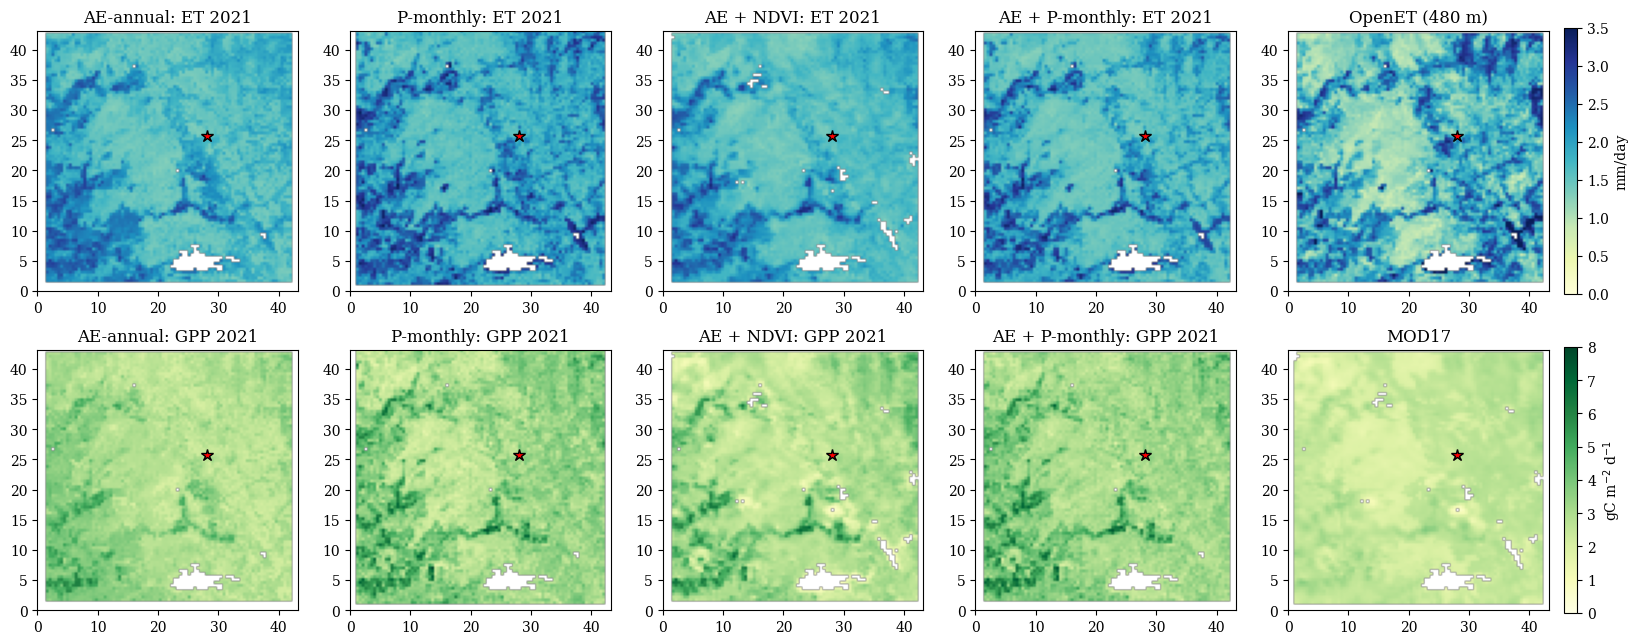

,r2 vs OpenET (annual ET),bias vs OpenET (mm/day),r2 vs MOD17 (annual GPP),bias vs MOD17
model,,,,
AE-annual,0.41,0.05,0.09,0.69
P-monthly,0.70,0.25,0.49,1.00
AE + NDVI,0.41,0.03,0.61,0.59
AE + P-monthly,0.66,0.08,0.37,1.04


In [11]:
fig, axs = plt.subplots(2, 5, figsize=(20, 7.6))
for j, k in enumerate(MAP_MODELS):
    im = axs[0, j].imshow(np.nanmean(maps[('ET', k)], axis=0), cmap='YlGnBu', vmin=0, vmax=3.5, extent=extent_km); axs[0, j].set_title(f'{k}: ET 2021')
    im2 = axs[1, j].imshow(np.nanmean(maps[('GPP', k)], axis=0), cmap='YlGn', vmin=0, vmax=8, extent=extent_km); axs[1, j].set_title(f'{k}: GPP 2021')
axs[0, 4].imshow(np.nanmean(openet, axis=0), cmap='YlGnBu', vmin=0, vmax=3.5, extent=extent_km); axs[0, 4].set_title('OpenET (480 m)')
axs[1, 4].imshow(np.nanmean(m17, axis=0), cmap='YlGn', vmin=0, vmax=8, extent=extent_km); axs[1, 4].set_title('MOD17')
fig.colorbar(im, ax=axs[0], fraction=0.015, pad=0.01, label='mm/day'); fig.colorbar(im2, ax=axs[1], fraction=0.015, pad=0.01, label='gC m$^{-2}$ d$^{-1}$')
for ax in axs.ravel():
    ax.plot(*tower_km('US-Var'), '*', color='red', mec='k', ms=9)
plt.show()

rows = []
for k in MAP_MODELS:
    a, b = np.nanmean(maps[('ET', k)], axis=0), np.nanmean(openet, axis=0); m = np.isfinite(a) & np.isfinite(b)
    rows.append({'model': k, 'r2 vs OpenET (annual ET)': np.corrcoef(a[m], b[m])[0, 1]**2, 'bias vs OpenET (mm/day)': np.mean(a[m] - b[m])})
    a, b = np.nanmean(maps[('GPP', k)], axis=0), np.nanmean(m17, axis=0); m = np.isfinite(a) & np.isfinite(b)
    rows[-1].update({'r2 vs MOD17 (annual GPP)': np.corrcoef(a[m], b[m])[0, 1]**2, 'bias vs MOD17': np.mean(a[m] - b[m])})
display(pd.DataFrame(rows).set_index('model').round(2))

R2  RMSE  bias   n
site   target model                               
US-Var ET     AE-annual      -0.22  1.06  0.50  12
              P-monthly      -0.21  1.06  0.64  12
              AE + NDVI      -0.20  1.05  0.56  12
              AE + P-monthly  0.12  0.90  0.48  12
       GPP    AE-annual      -0.14  2.35  0.33  12
              P-monthly       0.21  1.96  0.91  12
              AE + NDVI       0.66  1.28  0.52  12
              AE + P-monthly  0.34  1.79  0.88  12
US-Ton ET     AE-annual      -1.83  1.12  0.78  12
              P-monthly      -1.85  1.13  0.85  12
              AE + NDVI      -0.61  0.85  0.60  12
              AE + P-monthly -0.59  0.84  0.61  12
       GPP    AE-annual       0.07  1.27  0.45  12
              P-monthly      -1.13  1.92  1.18  12
              AE + NDVI       0.75  0.66  0.36  12
              AE + P-monthly -0.29  1.50  1.10  12

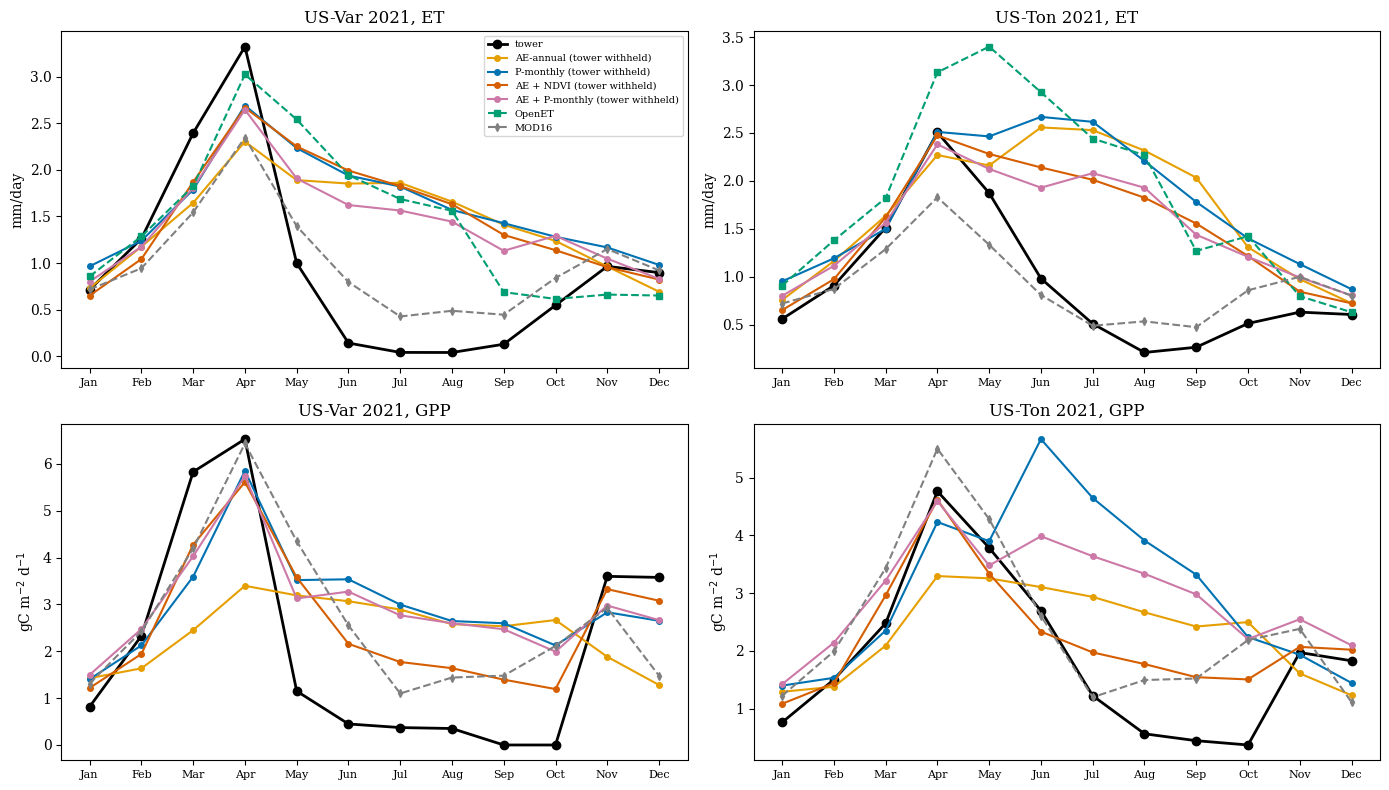

In [12]:
def series_at(arr, site):
    r, c = tower_rc(site); return arr[:, r, c]

mnames = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
for i, site in enumerate(['US-Var', 'US-Ton']):
    for j, t in enumerate(['ET', 'GPP']):
        ax = axs[j, i]
        obs = mon[(mon.site_id == site) & (mon.year == 2021)].set_index('month')[t].reindex(range(1, 13))
        ax.plot(range(1, 13), obs, 'ko-', lw=2, label='tower')
        for k in MAP_MODELS:
            ax.plot(range(1, 13), series_at(maps[(t, k)], site), 'o-', ms=4, color=MODEL_COLORS[k], label=f'{k} (tower withheld)')
        if t == 'ET':
            ax.plot(range(1, 13), series_at(openet, site), 's--', ms=4, color='#009E73', label='OpenET'); ax.plot(range(1, 13), series_at(m16, site), 'd--', ms=4, color='gray', label='MOD16')
        else:
            ax.plot(range(1, 13), series_at(m17, site), 'd--', ms=4, color='gray', label='MOD17')
        ax.set_xticks(range(1, 13)); ax.set_xticklabels(mnames, fontsize=8); ax.set_title(f'{site} 2021, {t}'); ax.set_ylabel('mm/day' if t == 'ET' else 'gC m$^{-2}$ d$^{-1}$')
        if i == 0 and j == 0: ax.legend(fontsize=7)
plt.tight_layout()
rows = []
for site in ['US-Var', 'US-Ton']:
    for t in ['ET', 'GPP']:
        obs = mon[(mon.site_id == site) & (mon.year == 2021)].set_index('month')[t].reindex(range(1, 13)).values
        for k in MAP_MODELS:
            rows.append({'site': site, 'target': t, 'model': k, **metrics(obs, series_at(maps[(t, k)], site))})
display(pd.DataFrame(rows).set_index(['site', 'target', 'model']).round(2))

## **What we learned**

The experiment asked a simple question, whether monthly Prithvi embeddings beat AlphaEarth's annual vector, and the answer has several parts.

**Temporal resolution helps Prithvi a lot.** Going from the annual mean of its monthly vectors to the monthly vectors themselves raises Prithvi's leave-site-out R$^2$ by about 0.04 for ET and 0.11 for GPP. The decomposition shows where: almost all of the gain is in the within-year anomalies, the seasonal cycle, exactly as the loops in Step 1 promised.

**But the model matters as much as the resolution.** At equal, annual resolution AlphaEarth beats Prithvi clearly (R$^2$ 0.81 versus 0.78 for ET, 0.81 versus 0.71 for GPP). The monthly Prithvi embedding needs all of its temporal advantage to reach parity with AlphaEarth's annual vector (0.817 versus 0.814 for ET, 0.818 versus 0.810 for GPP). A model trained to produce embeddings for downstream use (AlphaEarth) packs more flux-relevant information into 64 numbers than a frozen reconstruction model (Prithvi) does, even after a year of monthly observations.

**Prithvi's own temporal attention did not help when frozen.** Feeding four seasonal composites in one pass (P-seasonal) was *worse* than averaging twelve single-month embeddings. The multi-temporal encoder was pretrained to reconstruct masked pixels across dates, not to summarize a year, and without fine-tuning that capacity does not transfer.

**Learned phenology versus hand-made phenology.** On top of AlphaEarth, monthly Prithvi embeddings add about as much as monthly NDVI for ET (0.835 versus 0.827) and less than NDVI for GPP (0.844 versus 0.870). Sixty-four numbers from a 300-million-parameter model, run 16,000 times, carry slightly less usable phenology for photosynthesis than one normalized difference of two Landsat bands. Adding both gives no further gain: they carry the same information.

**Label efficiency.** For GPP the monthly Prithvi model is clearly more label-efficient than annual AlphaEarth at 10-80 towers, which is the low-label regime foundation models are meant for. For ET the curves are indistinguishable.

**Maps.** At 480 m the monthly Prithvi map matches OpenET's spatial pattern of annual ET markedly better than the annual AlphaEarth map does (r$^2$ 0.70 versus 0.41 across pixels), though with a larger positive bias; the woodland corridors and the irrigated valley floor stand out the way they do in OpenET. The coarser grid blurs the field boundaries that the 100 m AlphaEarth maps of Notebook 12 resolve. At the withheld towers the dry-summer overestimate of Notebook 12 is unchanged for every model: monthly embeddings do not fix an extrapolation problem, because the problem is in the training set, not in the surface description. For GPP at Tonzi Ranch the Prithvi-monthly model even produces a spurious June peak, a reminder that a richer input is also a richer way to be wrong outside the training domain.

**The practical reading.** If you can get monthly NDVI, AlphaEarth plus NDVI remains the best and cheapest description in this study. Monthly Prithvi embeddings are a credible substitute where you want a richer description than one index, and they are the only option among the two models for a *sub-annual* learned description. Fine-tuning Prithvi on flux data, rather than freezing it, is the obvious next step, and it is the reason the model ships as weights rather than as a product.

## **Exercises**

**Exercise 1.** The Prithvi vectors were reduced to 64 principal components to match AlphaEarth. Redo the P-monthly model with only the first 16 components, then with 8. How much skill survives, and what does that say about how the information is spread across the representation?

**Exercise 2.** `hls_valid_frac` tells you how much of each monthly chip was actually observed. Drop months with less than 50% valid pixels from both training and testing. Does the P-monthly model improve, and by how much does the training set shrink? Winter in which biomes is most affected?

**Exercise 3.** Build a "P-monthly + previous month" model by adding the embedding of month $m-1$ as features. Does the change in the surface between two months carry information that the current month alone does not?

**Exercise 4.** The within-year decomposition attributes skill to anomalies from the site-year mean. Repeat it with anomalies from the *site climatology* (the mean over all years for that calendar month). This isolates interannual anomalies, the hardest and most valuable target for drought monitoring. Which model wins there?

**Exercise 5 (compute).** `prithvi_embed.py` pooled the four patches around the tower. Change it to use the class token instead, or the mean of all 36 patches (a 2.9 km footprint), rerun for a subset of towers, and compare. Which pooling best represents what a flux tower measures?

## **References**

- Szwarcman, D., et al. (2024). Prithvi-EO-2.0: A versatile multi-temporal foundation model for Earth observation applications. *arXiv:2412.02732*. Weights: `ibm-nasa-geospatial/Prithvi-EO-2.0-300M` (Apache 2.0).
- Jakubik, J., et al. (2023). Foundation models for generalist geospatial artificial intelligence. *arXiv:2310.18660* (Prithvi-EO-1.0).
- Brown, C. F., et al. (2025). AlphaEarth Foundations: An embedding field model for accurate and efficient global mapping from sparse label data. *arXiv:2507.22291*.
- He, K., et al. (2022). Masked autoencoders are scalable vision learners. *CVPR 2022*.
- Cong, Y., et al. (2022). SatMAE: Pre-training transformers for temporal and multi-spectral satellite imagery. *NeurIPS 2022*.
- Tseng, G., et al. (2023). Lightweight, pre-trained transformers for remote sensing timeseries (Presto). *arXiv:2304.14065*.
- Claverie, M., et al. (2018). The Harmonized Landsat and Sentinel-2 surface reflectance data set. *Remote Sensing of Environment*, 219, 145-161.
- Jung, M., et al. (2019). The FLUXCOM ensemble of global land-atmosphere energy fluxes. *Scientific Data*, 6, 74.